In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df=pd.read_excel("p_2_study_build/cleaned_dataset.xlsx")

In [45]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   customer_id         60 non-null     int64         
 1   first_name          60 non-null     object        
 2   gender              60 non-null     object        
 3   age                 60 non-null     int64         
 4   city                60 non-null     object        
 5   province            60 non-null     object        
 6   signup_date         60 non-null     datetime64[ns]
 7   membership_tier     60 non-null     object        
 8   purchase_count      60 non-null     int64         
 9   avg_order_value     60 non-null     float64       
 10  total_spending      60 non-null     float64       
 11  last_purchase_days  60 non-null     int64         
 12  payment_method      60 non-null     object        
 13  device              60 non-null     object        
 

In [41]:
print(df.isnull().sum())
print(df.duplicated().sum())

customer_id           0
first_name            0
gender                0
age                   0
city                  0
province              0
signup_date           0
membership_tier       0
purchase_count        0
avg_order_value       0
total_spending        0
last_purchase_days    0
payment_method        0
device                0
discount_used         0
returned_items        0
satisfaction_score    0
dtype: int64
0


In [47]:
print(df[df.duplicated(keep=False)])

Empty DataFrame
Columns: [customer_id, first_name, gender, age, city, province, signup_date, membership_tier, purchase_count, avg_order_value, total_spending, last_purchase_days, payment_method, device, discount_used, returned_items, satisfaction_score]
Index: []


In [49]:
df=df.drop_duplicates()
print(df.duplicated().sum())
df.to_excel("p_2_study_build/cleaned_dataset.xlsx",index=False)

0


In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df=pd.read_excel('p_2_study_build/cleaned_dataset.xlsx')

analysis_df=df.dropna(
    subset=['gender','age','membership_tier','device','payment_method']
).copy()

In [53]:
age_bins=[0,24,34,44,54,64,np.inf]
age_labels=[
    'Under 25','25-35','35-45','45-55','55-65','65 and above'
]
analysis_df['age_group']=pd.cut(
    analysis_df['age'],bins=age_bins,labels=age_labels, include_lowest=True
)
analysis_df.to_excel("p_2_study_build/analysis_data.xlsx", index=False)


In [55]:
print(analysis_df.head())

   customer_id first_name gender  age     city         province signup_date  \
0         1001       Reza      M   19    Karaj           Alborz  2025-02-19   
1         1002       Sina      M   53   Tehran           Tehran  2022-08-19   
2         1003      Parsa      M   31   Shiraz             Fars  2023-06-20   
3         1004       Sina      M   58  Mashhad  Razavi Khorasan  2021-11-08   
4         1005      Kimia      F   28  Isfahan          Isfahan  2021-10-21   

  membership_tier  purchase_count  avg_order_value  total_spending  \
0             VIP              17           121.53         2066.01   
1            Gold              12           326.47         3917.64   
2            Gold              21            59.46         1248.66   
3            Gold              23           266.15         6121.45   
4          Silver              23           169.54         3899.42   

   last_purchase_days payment_method   device discount_used  returned_items  \
0                  16    

In [57]:
profile_summary = {
"customer_count": analysis_df["customer_id"].nunique(),
"avg_age": analysis_df["age"].mean(),
"median_age": analysis_df["age"].median(),
"most_common_gender": analysis_df["gender"].mode().iloc[0],
"most_common_membership": analysis_df["membership_tier"].mode().iloc[0],
"most_common_device": analysis_df["device"].mode().iloc[0],
"most_common_payment": analysis_df["payment_method"].mode().iloc[0]
}
print(profile_summary)

{'customer_count': 60, 'avg_age': np.float64(43.7), 'median_age': np.float64(45.0), 'most_common_gender': 'M', 'most_common_membership': 'Gold', 'most_common_device': 'Android', 'most_common_payment': 'Online Wallet'}


In [59]:
profile_table = pd.Series(profile_summary, name="value")
display(profile_table)

customer_count                       60
avg_age                            43.7
median_age                         45.0
most_common_gender                    M
most_common_membership             Gold
most_common_device              Android
most_common_payment       Online Wallet
Name: value, dtype: object

In [63]:
age_counts=analysis_df['age_group'].value_counts()
display(age_counts)

age_group
55-65           16
45-55           15
25-35           11
35-45           10
Under 25         7
65 and above     1
Name: count, dtype: int64

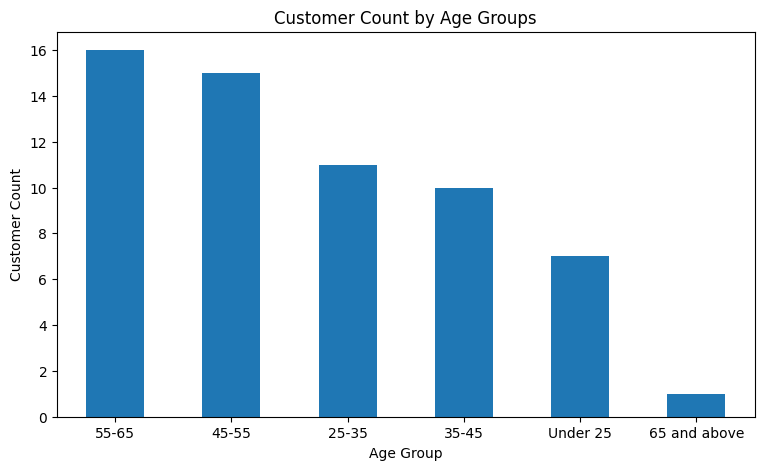

In [65]:
age_counts.plot(kind="bar", figsize=(9,5))

plt.title("Customer Count by Age Groups")
plt.xlabel("Age Group")
plt.ylabel("Customer Count")

plt.xticks(rotation=0)

plt.show()

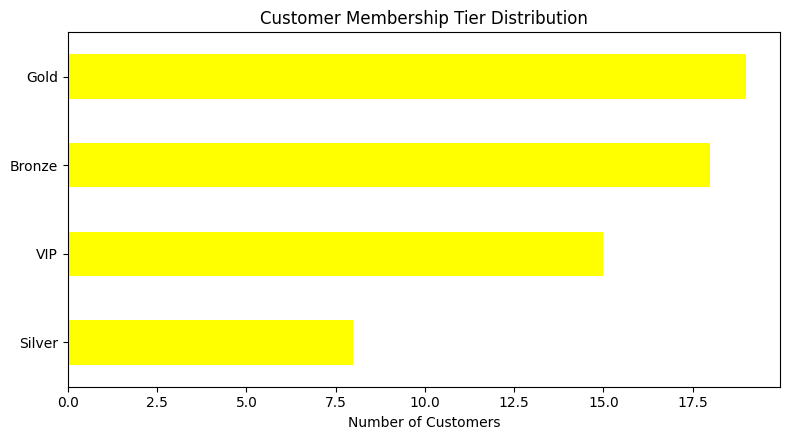

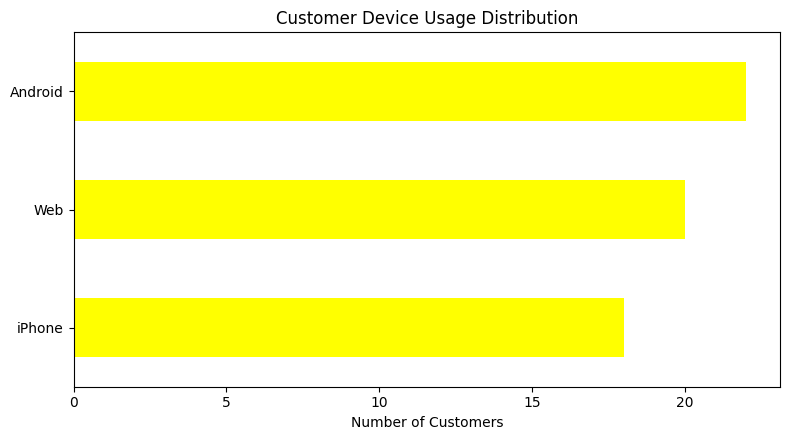

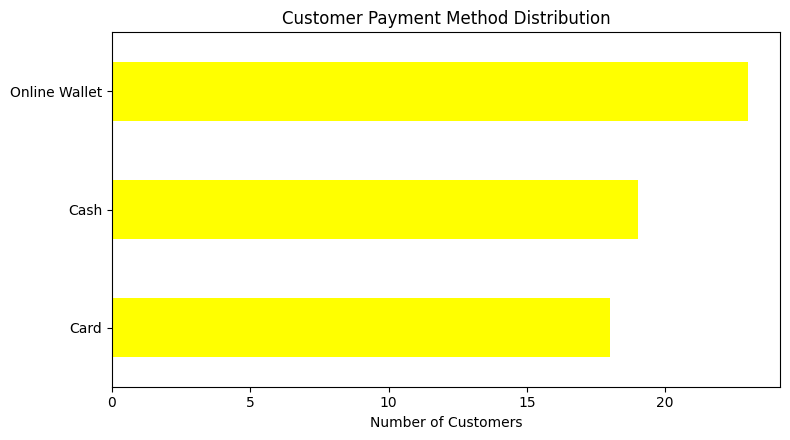

In [67]:
for column, title in [
    ("membership_tier", "Customer Membership Tier Distribution"),
    ("device", "Customer Device Usage Distribution"),
    ("payment_method", "Customer Payment Method Distribution")
]:
    counts = analysis_df[column].value_counts().sort_values(ascending=True)
    counts.plot(kind="barh", figsize=(8, 4.5), color='yellow')
    plt.title(title)
    plt.xlabel("Number of Customers")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df=pd.read_excel('p_2_study_build/cleaned_dataset.xlsx')

location_df = df.dropna(
    subset=[
        "province",
        "city",
        "customer_id",
        "total_spending",
        "satisfaction_score"
    ]
).copy()
location_df.shape

(60, 17)

In [71]:
city_summary = (
location_df.groupby(["province", "city"], as_index=False)
.agg(
customer_count=("customer_id", "nunique"),
total_revenue=("total_spending", "sum"),
avg_customer_spending=("total_spending", "mean"),
avg_purchase_count=("purchase_count", "mean"),
avg_order_value=("avg_order_value", "mean"),
avg_satisfaction=("satisfaction_score", "mean")
)
)
print(city_summary.head())

          province     city  customer_count  total_revenue  \
0           Alborz    Karaj               7       26189.81   
1  East Azarbaijan   Tabriz              12       36192.49   
2             Fars   Shiraz               6       20715.92   
3            Gilan    Rasht               5       15168.54   
4          Isfahan  Isfahan               5       21975.32   

   avg_customer_spending  avg_purchase_count  avg_order_value  \
0            3741.401429           16.000000       211.440000   
1            3016.040833           15.750000       238.901667   
2            3452.653333           16.333333       180.983333   
3            3033.708000           16.400000       241.554000   
4            4395.064000           19.800000       212.680000   

   avg_satisfaction  
0          2.857143  
1          3.000000  
2          2.000000  
3          2.600000  
4          4.400000  


In [73]:
city_summary = city_summary[
    city_summary["customer_count"] >= 3
].copy()
top_cities = city_summary.nlargest(
    10,
    "total_revenue"
).sort_values("total_revenue")

In [75]:
display(
top_cities.sort_values(
    "total_revenue",
    ascending=False
)
)

,province,city,customer_count,total_revenue,avg_customer_spending,avg_purchase_count,avg_order_value,avg_satisfaction
6,Razavi Khorasan,Mashhad,11,43174.44,3924.949091,22.636364,210.508182,2.909091
1,East Azarbaijan,Tabriz,12,36192.49,3016.040833,15.750000,238.901667,3.000000
0,Alborz,Karaj,7,26189.81,3741.401429,16.000000,211.440000,2.857143
5,Khuzestan,Ahvaz,8,23384.78,2923.097500,13.875000,208.572500,3.500000
4,Isfahan,Isfahan,5,21975.32,4395.064000,19.800000,212.680000,4.400000
2,Fars,Shiraz,6,20715.92,3452.653333,16.333333,180.983333,2.000000
3,Gilan,Rasht,5,15168.54,3033.708000,16.400000,241.554000,2.600000
7,Tehran,Tehran,6,15161.29,2526.881667,17.166667,172.930000,2.666667


In [77]:
city_summary.to_excel("city_summary.xlsx", index=False)

<BarContainer object of 8 artists>

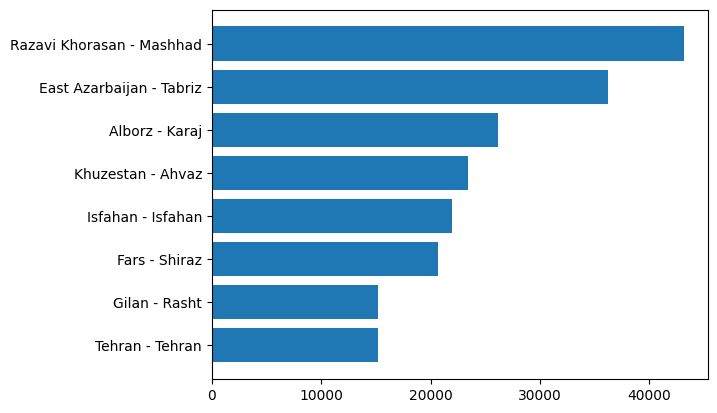

In [83]:
labels=top_cities['province'] + ' - ' + top_cities['city']
plt.barh(labels,top_cities['total_revenue'])

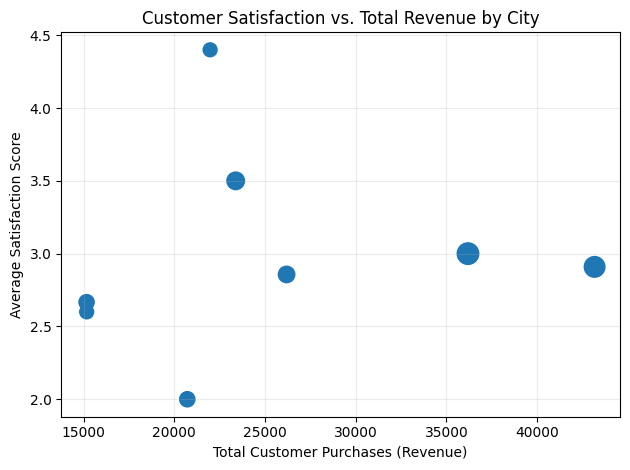

In [89]:
plt.scatter(
city_summary["total_revenue"],
city_summary["avg_satisfaction"],
s=city_summary["customer_count"] * 20
)
plt.title("Customer Satisfaction vs. Total Revenue by City")
plt.xlabel("Total Customer Purchases (Revenue)")
plt.ylabel("Average Satisfaction Score")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [91]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df=pd.read_excel('p_2_study_build/cleaned_dataset.xlsx')

loyalty_df = df.dropna(
    subset=[
        "customer_id",
        "first_name",
        "purchase_count",
        "total_spending",
        "last_purchase_days",
        "satisfaction_score"
    ]
).copy()

In [93]:
for column in ["purchase_count", "total_spending", "satisfaction_score"]:
    minimum = loyalty_df[column].min()
    maximum = loyalty_df[column].max()
    if maximum == minimum:
     loyalty_df[f"{column}_score"] = 1.0
    else:
     loyalty_df[f"{column}_score"] = (
     loyalty_df[column] - minimum
     )/ (maximum - minimum)
     
loyalty_df.head()

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score,purchase_count_score,total_spending_score,satisfaction_score_score
0,1001,Reza,M,19,Karaj,Alborz,2025-02-19,VIP,17,121.53,2066.01,16,Card,Android,Yes,3,5,0.485714,0.143929,1.00
1,1002,Sina,M,53,Tehran,Tehran,2022-08-19,Gold,12,326.47,3917.64,3,Card,Web,No,5,3,0.342857,0.272924,0.50
2,1003,Parsa,M,31,Shiraz,Fars,2023-06-20,Gold,21,59.46,1248.66,22,Online Wallet,iPhone,Yes,6,1,0.600000,0.086988,0.00
3,1004,Sina,M,58,Mashhad,Razavi Khorasan,2021-11-08,Gold,23,266.15,6121.45,40,Card,Android,No,4,4,0.657143,0.426453,0.75
4,1005,Kimia,F,28,Isfahan,Isfahan,2021-10-21,Silver,23,169.54,3899.42,273,Online Wallet,Android,Yes,7,4,0.657143,0.271654,0.75


In [95]:
recency_min = loyalty_df["last_purchase_days"].min()
recency_max = loyalty_df["last_purchase_days"].max()
if recency_max == recency_min:
 loyalty_df["recency_score"] = 1.0
else:
 loyalty_df["recency_score"] = 1 -(
 (loyalty_df["last_purchase_days"] - recency_min)
 / (recency_max - recency_min))
loyalty_df.head()

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,...,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score,purchase_count_score,total_spending_score,satisfaction_score_score,recency_score
0,1001,Reza,M,19,Karaj,Alborz,2025-02-19,VIP,17,121.53,...,16,Card,Android,Yes,3,5,0.485714,0.143929,1.00,0.964088
1,1002,Sina,M,53,Tehran,Tehran,2022-08-19,Gold,12,326.47,...,3,Card,Web,No,5,3,0.342857,0.272924,0.50,1.000000
2,1003,Parsa,M,31,Shiraz,Fars,2023-06-20,Gold,21,59.46,...,22,Online Wallet,iPhone,Yes,6,1,0.600000,0.086988,0.00,0.947514
3,1004,Sina,M,58,Mashhad,Razavi Khorasan,2021-11-08,Gold,23,266.15,...,40,Card,Android,No,4,4,0.657143,0.426453,0.75,0.897790
4,1005,Kimia,F,28,Isfahan,Isfahan,2021-10-21,Silver,23,169.54,...,273,Online Wallet,Android,Yes,7,4,0.657143,0.271654,0.75,0.254144


In [97]:
loyalty_df["loyalty_score"] = (
0.35* loyalty_df["total_spending_score"]
+ 0.30 * loyalty_df["purchase_count_score"]
+ 0.20 * loyalty_df["recency_score"]
) + 0.15 * loyalty_df["satisfaction_score_score"]

top_loyal_customers = loyalty_df.nlargest(10, "loyalty_score")[[ "customer_id", "first_name",
"membership_tier", "purchase_count", "total_spending", 
"last_purchase_days", "satisfaction_score", "loyalty_score"]]

display(top_loyal_customers)
top_loyal_customers.to_excel("top_loyal_customers.xlsx", index=False)

,customer_id,first_name,membership_tier,purchase_count,total_spending,last_purchase_days,satisfaction_score,loyalty_score
56,1057,Maryam,Bronze,31,13532.74,82,4,0.864535
43,1044,Mina,Gold,33,14354.34,165,2,0.780854
58,1059,Ali,Gold,31,8898.55,224,5,0.710587
8,1009,Kimia,Silver,34,11615.42,232,2,0.685627
3,1004,Sina,Gold,23,6121.45,40,4,0.638459
11,1012,Arash,Gold,27,11731.50,224,2,0.632877
32,1033,Neda,VIP,24,5521.20,112,5,0.630116
13,1014,Reza,VIP,31,3353.89,97,4,0.608058
22,1023,Ali,Bronze,31,3851.44,170,4,0.579858
16,1017,Parsa,VIP,30,3239.40,135,4,0.575701


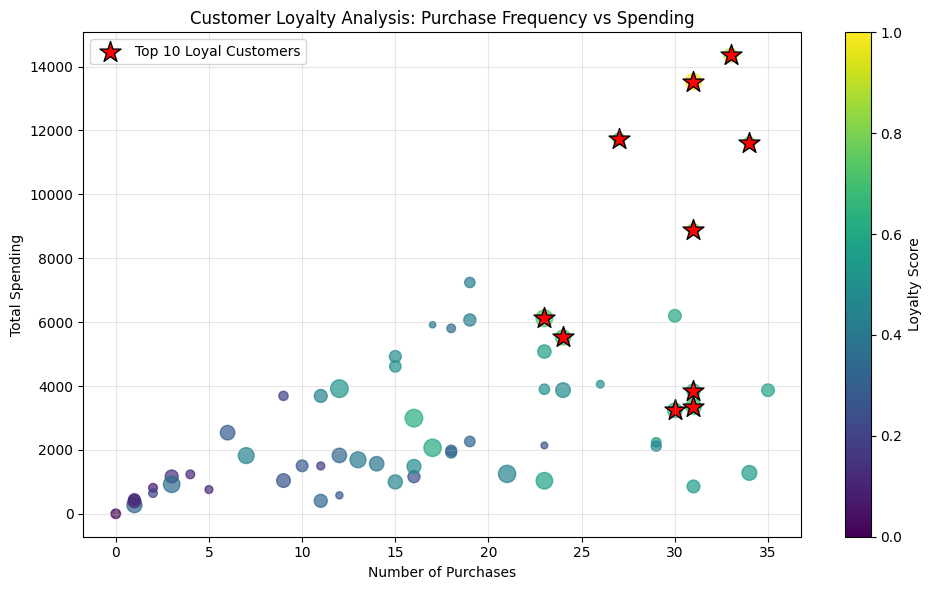

In [99]:
plt.figure(figsize=(10, 6))

plt.scatter(
    loyalty_df["purchase_count"],
    loyalty_df["total_spending"],
    s=(loyalty_df["recency_score"] + 0.15) * 140,
    c=loyalty_df["loyalty_score"],
    cmap="viridis",
    alpha=0.7
)

plt.scatter(
    top_loyal_customers["purchase_count"],
    top_loyal_customers["total_spending"],
    s=250,
    marker="*",
    c="red",
    edgecolors="black",
    label="Top 10 Loyal Customers"
)

plt.title("Customer Loyalty Analysis: Purchase Frequency vs Spending")
plt.xlabel("Number of Purchases")
plt.ylabel("Total Spending")

plt.colorbar(label="Loyalty Score")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [101]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df=pd.read_excel('p_2_study_build/cleaned_dataset.xlsx')

risk_df = df.dropna(
    subset=[
        "customer_id",
        "first_name",
        "total_spending",
        "purchase_count",
        "last_purchase_days"
    ]
).copy()
spending_threshold = risk_df["total_spending"].quantile(0.75)
purchase_threshold = risk_df["purchase_count"].median()
inactivity_threshold = risk_df["last_purchase_days"].quantile(0.75)


In [103]:
risk_df["at_risk"] = (
(risk_df["total_spending"] >= spending_threshold)
& (risk_df["purchase_count"] >= purchase_threshold)
& (risk_df["last_purchase_days"] >= inactivity_threshold)
)
risk_df.head()

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score,at_risk
0,1001,Reza,M,19,Karaj,Alborz,2025-02-19,VIP,17,121.53,2066.01,16,Card,Android,Yes,3,5,False
1,1002,Sina,M,53,Tehran,Tehran,2022-08-19,Gold,12,326.47,3917.64,3,Card,Web,No,5,3,False
2,1003,Parsa,M,31,Shiraz,Fars,2023-06-20,Gold,21,59.46,1248.66,22,Online Wallet,iPhone,Yes,6,1,False
3,1004,Sina,M,58,Mashhad,Razavi Khorasan,2021-11-08,Gold,23,266.15,6121.45,40,Card,Android,No,4,4,False
4,1005,Kimia,F,28,Isfahan,Isfahan,2021-10-21,Silver,23,169.54,3899.42,273,Online Wallet,Android,Yes,7,4,False


In [105]:
at_risk_customers = risk_df.loc[
    risk_df["at_risk"],
    [
        "customer_id",
        "first_name",
        "membership_tier",
        "purchase_count",
        "total_spending",
        "last_purchase_days",
        "satisfaction_score"
    ]
].sort_values(
    ["total_spending", "last_purchase_days"],
    ascending=[False, False]
)

display(at_risk_customers)

print("Number of at-risk customers:", len(at_risk_customers))
at_risk_customers.to_excel("at_risk_customers.xlsx", index=False)

,customer_id,first_name,membership_tier,purchase_count,total_spending,last_purchase_days,satisfaction_score
9,1010,Arash,Silver,19,7241.47,276,1
34,1035,Arash,Bronze,17,5918.21,365,3
52,1053,Sina,Gold,18,5805.54,320,1


Number of at-risk customers: 3


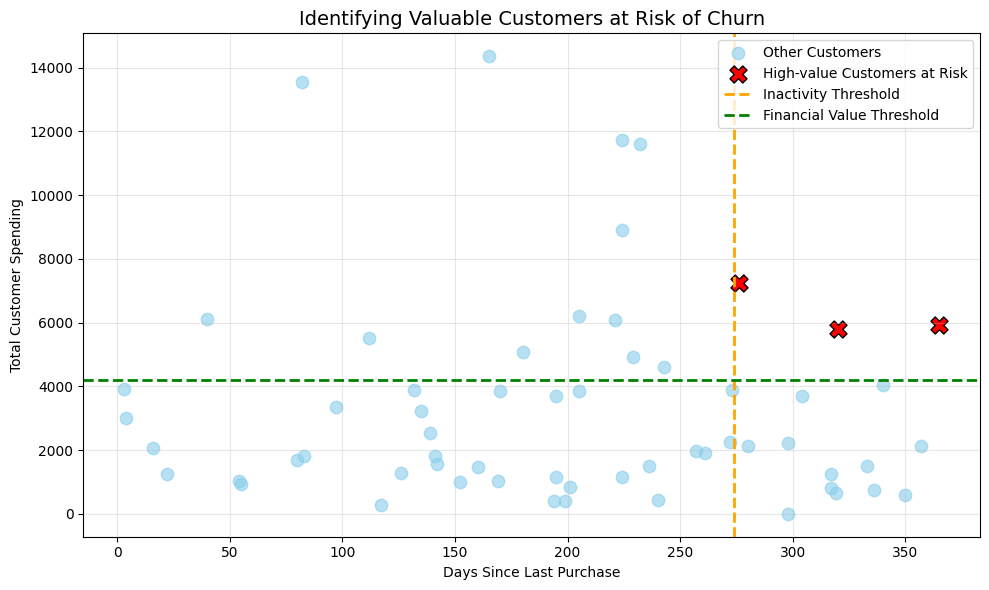

In [107]:
plt.figure(figsize=(10, 6))

# Other customers
plt.scatter(
    risk_df.loc[~risk_df["at_risk"], "last_purchase_days"],
    risk_df.loc[~risk_df["at_risk"], "total_spending"],
    c="skyblue",
    alpha=0.6,
    s=80,
    label="Other Customers"
)

# High-value customers at risk
plt.scatter(
    risk_df.loc[risk_df["at_risk"], "last_purchase_days"],
    risk_df.loc[risk_df["at_risk"], "total_spending"],
    c="red",
    marker="X",
    s=150,
    edgecolors="black",
    label="High-value Customers at Risk"
)

# Inactivity threshold line
plt.axvline(
    inactivity_threshold,
    linestyle="--",
    c="orange",
    linewidth=2,
    label="Inactivity Threshold"
)

# Financial value threshold line
plt.axhline(
    spending_threshold,
    linestyle="--",
    c="green",
    linewidth=2,
    label="Financial Value Threshold"
)


plt.title("Identifying Valuable Customers at Risk of Churn", fontsize=14)

plt.xlabel("Days Since Last Purchase")

plt.ylabel("Total Customer Spending")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [109]:
factor_df = df.dropna(
    subset=[
        "discount_used",
        "device",
        "payment_method",
        "total_spending",
        "purchase_count",
        "avg_order_value",
        "returned_items",
        "satisfaction_score"
    ]
).copy()

summary_by_discount = (
    factor_df.groupby("discount_used", as_index=False)
    .agg(
        customer_count=("customer_id", "nunique"),
        avg_total_spending=("total_spending", "mean"),
        avg_purchase_count=("purchase_count", "mean"),
        avg_order_value=("avg_order_value", "mean"),
        avg_returned_items=("returned_items", "mean"),
        avg_satisfaction=("satisfaction_score", "mean")
    )
)

display(summary_by_discount)
summary_by_discount.to_excel("summary_by_discount.xlsx", index=False)

,discount_used,customer_count,avg_total_spending,avg_purchase_count,avg_order_value,avg_returned_items,avg_satisfaction
0,No,34,3736.741176,17.294118,218.827941,4.264706,2.764706
1,Yes,26,2881.284231,17.500000,203.291154,4.076923,3.269231


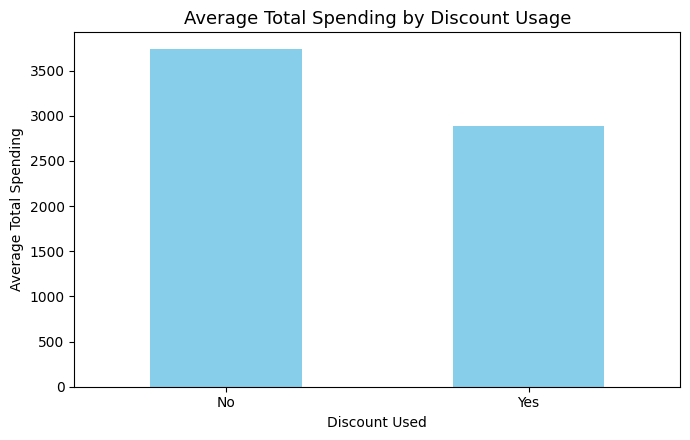

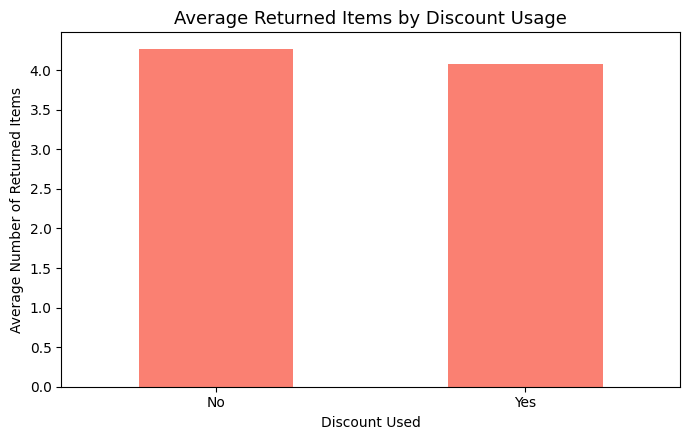

In [111]:
metrics = [
    (
        "avg_total_spending",
        "Average Total Spending by Discount Usage",
        "Average Total Spending"
    ),
    (
        "avg_returned_items",
        "Average Returned Items by Discount Usage",
        "Average Number of Returned Items"
    )
]


colors = ["skyblue", "salmon"]


for (metric, title, ylabel), color in zip(metrics, colors):

    ax = summary_by_discount.plot(
        x="discount_used",
        y=metric,
        kind="bar",
        legend=False,
        figsize=(7, 4.5),
        color=color
    )

    plt.title(title, fontsize=13)

    plt.xlabel("Discount Used")

    plt.ylabel(ylabel)

    plt.xticks(rotation=0)

    plt.tight_layout()

    plt.show()

,count,mean
device,,
Web,20,2896.603000
Android,22,3459.069091
iPhone,18,3773.945000


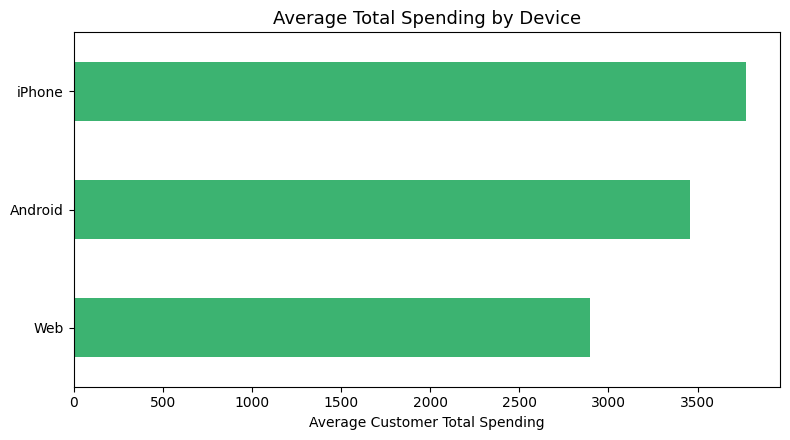

,count,mean
payment_method,,
Online Wallet,23,3104.462174
Cash,19,3149.361579
Card,18,3929.005000


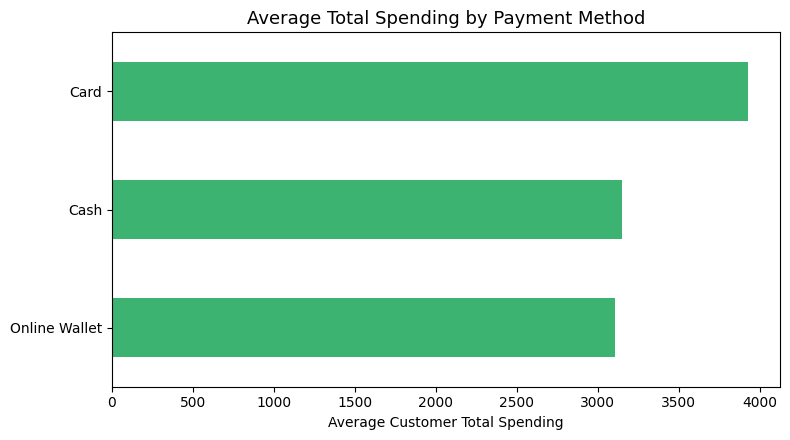

In [113]:
for factor, title in [
    ("device", "Average Total Spending by Device"),
    ("payment_method", "Average Total Spending by Payment Method")
]:

    factor_summary = (
        factor_df.groupby(factor)["total_spending"]
        .agg(["count", "mean"])
        .query("count >= 3")
        .sort_values("mean", ascending=True)
    )

    display(factor_summary)

    factor_summary["mean"].plot(
        kind="barh",
        figsize=(8, 4.5),
        color="mediumseagreen"
    )

    plt.title(title, fontsize=13)
    plt.xlabel("Average Customer Total Spending")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

In [115]:
kpi_summary = pd.Series(
    {
        "Unique Customers": df["customer_id"].nunique(),
        "Total Customer Spending": df["total_spending"].sum(),
        "Average Customer Spending": df["total_spending"].mean(),
        "Average Purchase Count": df["purchase_count"].mean(),
        "Average Satisfaction Score": df["satisfaction_score"].mean(),
        "Total Returned Items": df["returned_items"].sum()
    },
    name="Value"
)

display(kpi_summary)

Unique Customers                  60.000000
Total Customer Spending       201962.590000
Average Customer Spending       3366.043167
Average Purchase Count            17.383333
Average Satisfaction Score         2.983333
Total Returned Items             251.000000
Name: Value, dtype: float64

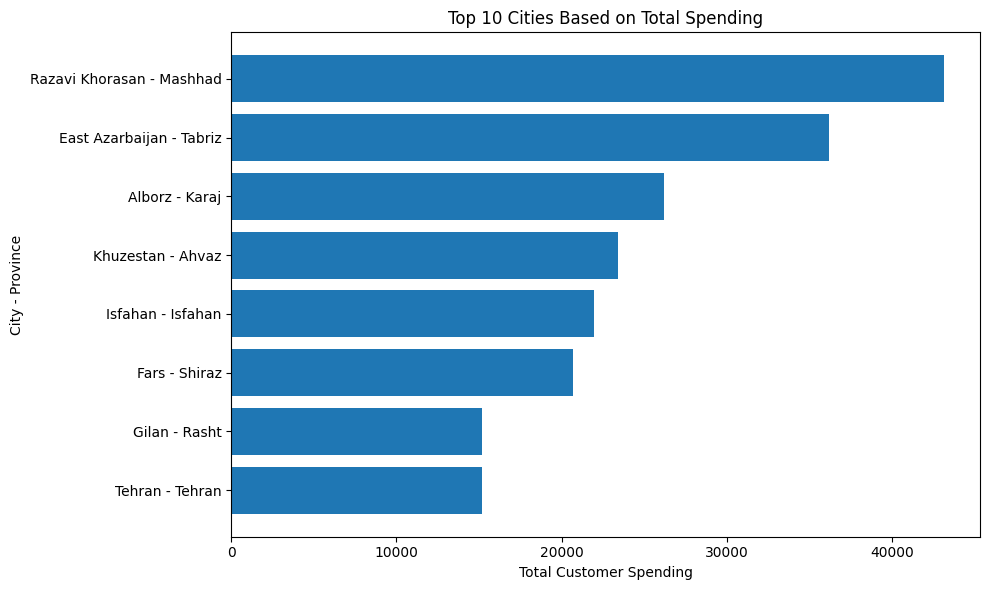

In [117]:
chart1 = (
    city_summary
    .nlargest(10, "total_revenue")
    .sort_values("total_revenue")
)

chart1_labels = chart1["province"] + " - " + chart1["city"]

plt.figure(figsize=(10, 6))

plt.barh(
    chart1_labels,
    chart1["total_revenue"]
)

plt.title("Top 10 Cities Based on Total Spending")
plt.xlabel("Total Customer Spending")
plt.ylabel("City - Province")

plt.tight_layout()
plt.show()

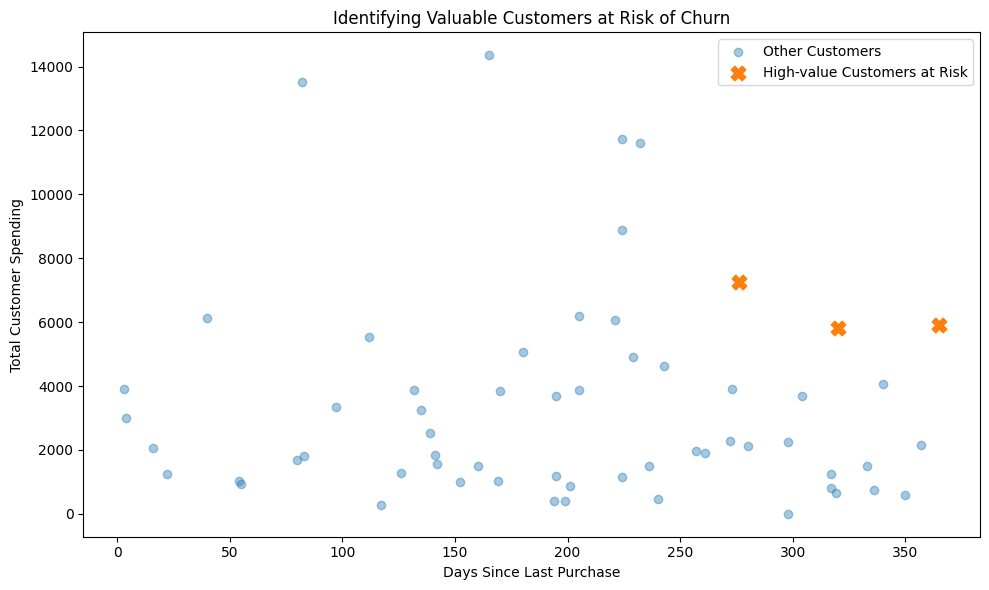

In [121]:
# Chart 2: High-value Customers at Risk

plt.figure(figsize=(10, 6))


# Other customers
plt.scatter(
    risk_df.loc[~risk_df["at_risk"], "last_purchase_days"],
    risk_df.loc[~risk_df["at_risk"], "total_spending"],
    alpha=0.4,
    label="Other Customers"
)


# Valuable customers at risk
plt.scatter(
    risk_df.loc[risk_df["at_risk"], "last_purchase_days"],
    risk_df.loc[risk_df["at_risk"], "total_spending"],
    marker="X",
    s=110,
    label="High-value Customers at Risk"
)


plt.title("Identifying Valuable Customers at Risk of Churn")

plt.xlabel("Days Since Last Purchase")

plt.ylabel("Total Customer Spending")

plt.legend()

plt.tight_layout()

plt.show()



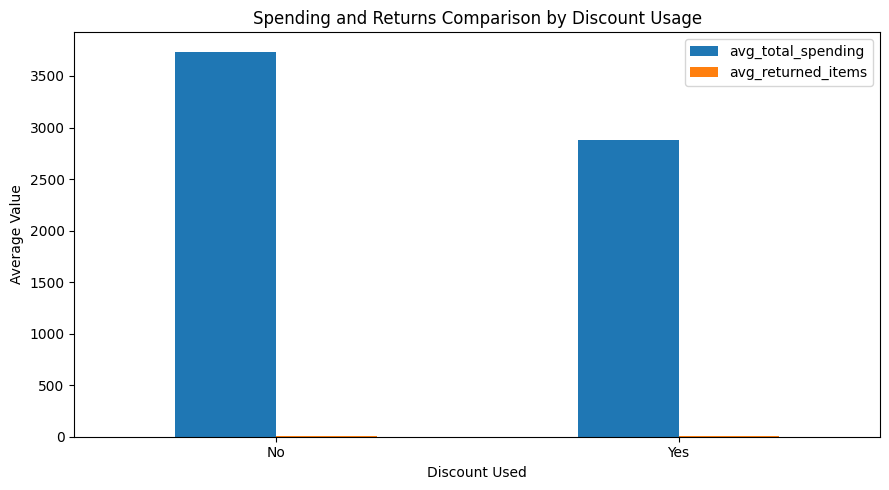

In [123]:
# Chart 3: Discount Impact Comparison

summary_by_discount.plot(
    x="discount_used",
    y=[
        "avg_total_spending",
        "avg_returned_items"
    ],
    kind="bar",
    figsize=(9, 5)
)


plt.title("Spending and Returns Comparison by Discount Usage")

plt.xlabel("Discount Used")

plt.ylabel("Average Value")

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()



In [125]:
# Save Main Analysis Tables

with pd.ExcelWriter("customer_analytics_results.xlsx") as writer:

    kpi_summary.to_excel(
        writer,
        sheet_name="KPI"
    )

    city_summary.to_excel(
        writer,
        sheet_name="City Analysis",
        index=False
    )

    top_loyal_customers.to_excel(
        writer,
        sheet_name="Top Loyal Customers",
        index=False
    )

    at_risk_customers.to_excel(
        writer,
        sheet_name="At Risk Customers",
        index=False
    )

    summary_by_discount.to_excel(
        writer,
        sheet_name="Discount Analysis",
        index=False
    )


print("customer_analytics_results.xlsx saved successfully")

customer_analytics_results.xlsx saved successfully


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=e864f0be-766d-497c-86a8-35e7d89c428e' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>